# <span style='color: pink'>**Advance Coding Project - Madrid Air Quality**</span>
### **Group "Future data scientists"**
Giulia Castelli (300691), Anna Granzotto (300051), Maria Maggiora (297281)

### **Import packages**

In [1]:
import pandas as pd
import numpy as np
import fsspec
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

/Users/giuli/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### **Load Data**

In [2]:
# Option A: sample CSV for development (default)
df_original = pd.read_csv("data/sample_dataset.csv")

# Option B: full dataset from HuggingFace (uncomment when ready)
# files = fsspec.open_files(
#     "hf://datasets/dmariaa70/METRAQ-Air-Quality/**/*.csv",
#     expand=True
# )
# df_original = pd.concat(
#     [pd.read_csv(f.open()) for f in files],
#     ignore_index=True
# )

## **Task 1 — Load Data and Inspect Structure**

### **Exploratory data analysis (EDA)**

We begin our analysis with Exploratory Data Analysis (EDA), a critical first step in understanding the dataset. This process helps reveal the structure of the data, identify unusual values, and uncover patterns using visual tools like graphs and charts. It also plays a key role in ensuring the data is clean and reliable for further analysis. 

#### 1.1) Data Overview and Initial Inspection 

We inspect the raw structure of the dataset: column names, data types, and a preview of the first rows. This confirms the schema matches the documentation and that columns were loaded with the correct types. We create a copy of df_original and work on df throughout the analysis, so the raw data is always available for reference.

In [3]:
df_original = pd.read_csv("data/sample_dataset.csv")
df = df_original.copy() 
df.head()

,sensor_id,sensor_name,utm_x,utm_y,magnitude_id,magnitude_name,entry_date,value,is_interpolated
0,28079008,Escuelas Aguirre,442117.2366,4474770.696,12,NOX,2006-08-16 01:00:00,56.000000,False
1,28079039,Barrio del Pilar,439689.0496,4481081.619,88,RS,2024-03-21 05:00:00,1.045836,True
2,28079057,Sanchinarro,444026.8080,4482820.581,1023,OC_IDW,2020-03-13 00:00:00,0.000000,False
3,28079049,Parque del Retiro,442095.5200,4473981.740,89,PRECIPITACION,2021-01-30 04:00:00,0.000000,True
4,28079060,Tres Olivos,441556.7005,4483543.994,1023,OC_IDW,2023-12-19 09:00:00,15.933061,False


We analyze the data dimensions using .shape. The number of rows reflects the total measurements loaded, and will differ between the sample and the full dataset.

In [4]:
print(f"Number of rows and columns: {df.shape}")

Number of rows and columns: (100000, 9)


We now get the Column names, which is the list of all features in the dataset.

In [5]:
print(df.columns.tolist())

['sensor_id', 'sensor_name', 'utm_x', 'utm_y', 'magnitude_id', 'magnitude_name', 'entry_date', 'value', 'is_interpolated']


We now get Data types, which specifies the type of each column, such as *str* for categorical features, *float64* or *int64* for numerical features and *bool* for boolean variables.

In [6]:
print(df.dtypes)

sensor_id            int64
sensor_name         object
utm_x              float64
utm_y              float64
magnitude_id         int64
magnitude_name      object
entry_date          object
value              float64
is_interpolated       bool
dtype: object


Although the dataset was previously verified to have missing values handled, this step is performed to ensure that no missing data remain and to guarantee dataset consistency. The output displays the number of missing values in each column, allowing us to detect any remaining incomplete data.

NOTE: We check for fully null columns as part of the EDA's schema inspection. The deeper analysis of missingness patterns — including interpolated values, temporal gaps, and invalid readings — is carried out in Task 2.

In [7]:
missing_table = df.isna().sum().reset_index()
missing_table.columns = ["Column", "Missing Values"]
missing_table

,Column,Missing Values
0,sensor_id,0
1,sensor_name,0
2,utm_x,0
3,utm_y,0
4,magnitude_id,0
5,magnitude_name,0
6,entry_date,0
7,value,0
8,is_interpolated,0


#### 1.2) Dataset Description

In [8]:
print(f"Total rows      : {len(df):,}")
print(f"Unique sensors  : {df['sensor_name'].nunique()}")
print(f"Unique variables: {df['magnitude_name'].nunique()}")
print(f"Start date      : {df['entry_date'].min()}")
print(f"End date        : {df['entry_date'].max()}")

Total rows      : 100,000
Unique sensors  : 24
Unique variables: 36
Start date      : 2001-01-01 10:00:00
End date        : 2024-12-31 20:00:00


In [9]:
# Classify each row by variable type
pollutants = [
    "CO", "NO", "NO2", "NOX", "SO2", "<PM10", "<PM2.5", "O3",
    "TOLUENO", "BENCENO", "ETILBENCENO",
    "HIDROCARBS_TOTALES", "METANO", "HIDROCARBS_NO_METANICOS"
]
weather = ["VV", "DV", "TEMP", "HR", "PRE", "RS", "PRECIPITACION"]
traffic_mask = df["magnitude_name"].str.startswith(("TI_", "SP_", "OC_"), na=False)
traffic_vars = sorted(df.loc[traffic_mask, "magnitude_name"].unique())

def classify_variable(name):
    if name in pollutants:
        return "pollutant"
    elif name in weather:
        return "weather"
    elif name in traffic_vars:
        return "traffic"
    else:
        return "other"

df["variable_type"] = df["magnitude_name"].apply(classify_variable)

# Scale breakdown table
scale_summary = df.groupby("variable_type").size().rename("rows").reset_index()
scale_summary["percentage"] = (scale_summary["rows"] / len(df) * 100).round(2)
display(scale_summary)

,variable_type,rows,percentage
0,pollutant,39369,39.37
1,traffic,47164,47.16
2,weather,13467,13.47


#### 1.3) Time Coverage

The project documentation explicitly warns that not all variables are available throughout the entire time span. Here we quantify the date range of each variable and visualize sensor activity over time, which is critical for deciding which time window to use in later tasks.

In [10]:
# Date range and span per variable
time_coverage = (
    df.groupby("magnitude_name")["entry_date"]
    .agg(["min", "max", "count"])
    .assign(
        min=lambda x: pd.to_datetime(x["min"]),
        max=lambda x: pd.to_datetime(x["max"]),
        span_years=lambda x: (
            pd.to_datetime(x["max"]) - pd.to_datetime(x["min"])
        ).dt.days / 365
    )
    .sort_values("span_years", ascending=False)
    .round({"span_years": 1})
)
display(time_coverage)

,min,max,count,span_years
magnitude_name,,,,
NO,2001-01-01 14:00:00,2024-12-31 13:00:00,6397,24.0
NO2,2001-01-01 22:00:00,2024-12-31 13:00:00,6268,24.0
O3,2001-01-02 07:00:00,2024-12-30 11:00:00,3519,24.0
NOX,2001-01-01 10:00:00,2024-12-30 03:00:00,6403,24.0
CO,2001-01-04 06:00:00,2024-12-26 12:00:00,2689,24.0
<PM10,2001-01-05 16:00:00,2024-12-26 07:00:00,3221,24.0
SO2,2001-01-02 14:00:00,2024-12-21 23:00:00,2789,24.0
BENCENO,2001-01-08 10:00:00,2024-12-26 10:00:00,1458,24.0
TOLUENO,2001-01-26 12:00:00,2024-12-31 09:00:00,1395,23.9


We visualize sensor activity as a heatmap: each row is a sensor, each column is a year, and green means the sensor was active that year. This immediately shows which sensors have gaps and which are consistently available.

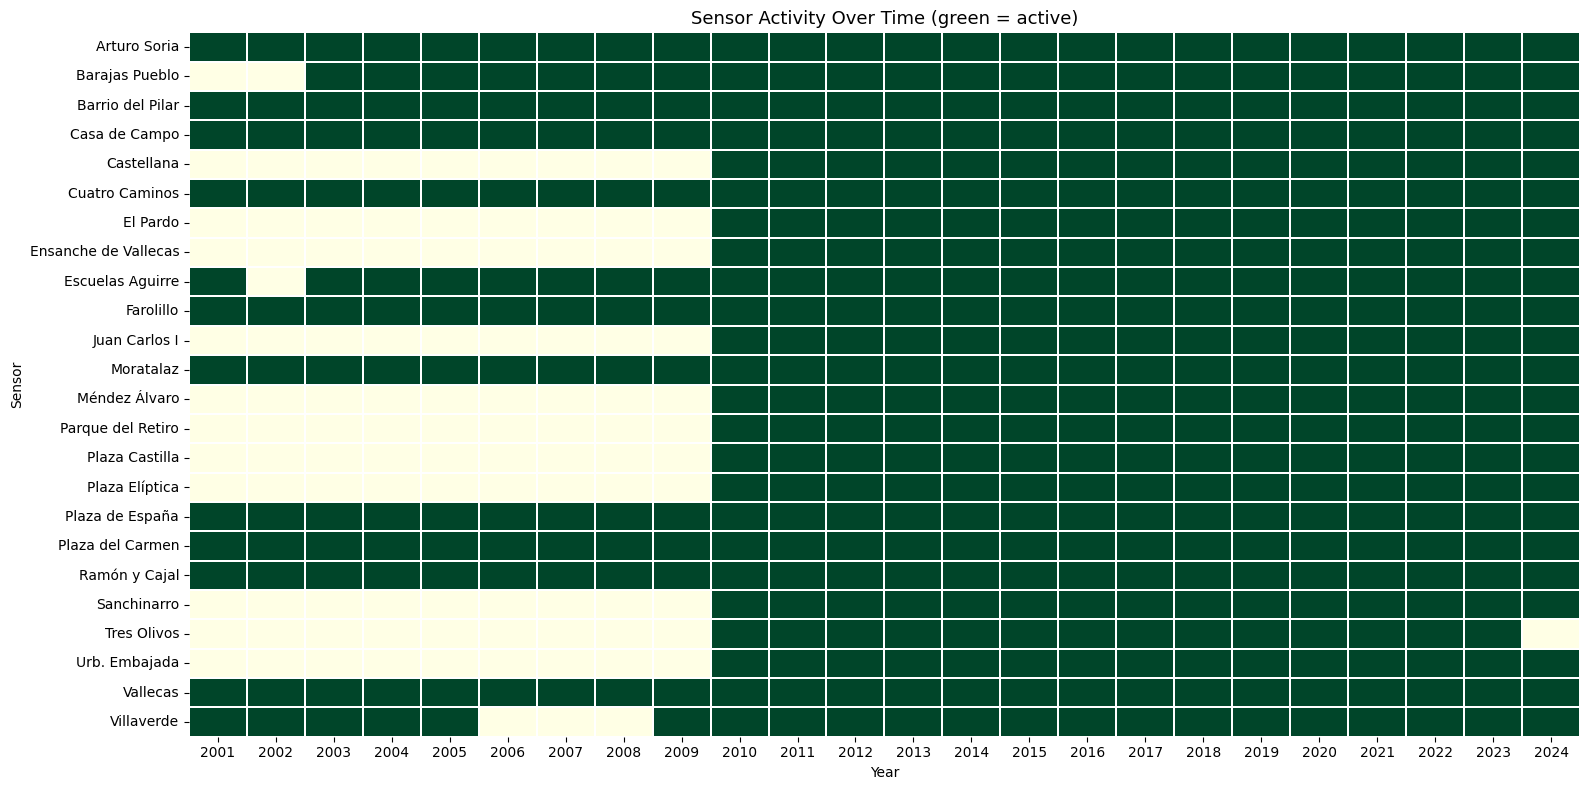

In [11]:
df["year"] = pd.to_datetime(df["entry_date"], errors="coerce").dt.year

availability = (
    df.groupby(["sensor_name", "year"])
    .size()
    .unstack(fill_value=0)
    .gt(0)
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(availability, cmap="YlGn", linewidths=0.3, ax=ax, cbar=False)
ax.set_title("Sensor Activity Over Time (green = active)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Sensor")
plt.tight_layout()
plt.show()

**What we observe: Sensor Activity**

The heatmap reveals that sensor coverage is not uniform across time. Some stations have been active since the early 2000s, while others — particularly those measuring traffic variables — only appear in later years. This confirms the project documentation's warning that not all variables are simultaneously available throughout the full time span. For tasks requiring all three categories (pollutants, weather, traffic) to overlap, we should restrict the analysis to the period where all are consistently present, which based on this heatmap appears to be approximately from 2018 onward. This time window decision will be confirmed when building the correlation and forecasting models in later tasks.

#### 1.4) Identification of Pollutants, Weather and Traffic Variables

The dataset contains different types of variables that describe air quality conditions. To make the analysis more structured, we group these variables into three main categories:
- `Air pollutant variables`
- `Meteorological variables`
- `Traffic variables`

In [12]:
df_pollutants = df[df["magnitude_name"].isin(pollutants)].copy()
df_weather    = df[df["magnitude_name"].isin(weather)].copy()
df_traffic    = df[df["magnitude_name"].isin(traffic_vars)].copy()

print(f"Pollutants found : {[p for p in pollutants if p in df['magnitude_name'].values]}")
print(f"Weather found    : {[w for w in weather if w in df['magnitude_name'].values]}")
print(f"Traffic found    : {traffic_vars}")
print()
print(f"Pollutant rows : {len(df_pollutants):,}")
print(f"Weather rows   : {len(df_weather):,}")
print(f"Traffic rows   : {len(df_traffic):,}")

Pollutants found : ['CO', 'NO', 'NO2', 'NOX', 'SO2', '<PM10', '<PM2.5', 'O3', 'TOLUENO', 'BENCENO', 'ETILBENCENO', 'HIDROCARBS_TOTALES', 'METANO', 'HIDROCARBS_NO_METANICOS']
Weather found    : ['VV', 'DV', 'TEMP', 'HR', 'PRE', 'RS', 'PRECIPITACION']
Traffic found    : ['OC_IDW', 'OC_KRIGING', 'OC_RBF_GAUSSIAN', 'OC_RBF_LINEAR', 'OC_RBF_MULTIQUADRIQ', 'SP_IDW', 'SP_KRIGING', 'SP_RBF_GAUSSIAN', 'SP_RBF_LINEAR', 'SP_RBF_MULTIQUADRIQ', 'TI_IDW', 'TI_KRIGING', 'TI_RBF_GAUSSIAN', 'TI_RBF_LINEAR', 'TI_RBF_MULTICUADRIC']

Pollutant rows : 39,369
Weather rows   : 13,467
Traffic rows   : 47,164


For each category, we show which sensors contributed data and over what time range.

In [13]:
pollutant_table = df_pollutants.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"])
display(pollutant_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Casa de Campo,2001-01-01 22:00:00,2024-12-30 11:00:00,4137
Escuelas Aguirre,2001-01-04 02:00:00,2024-12-29 13:00:00,3909
Farolillo,2001-01-03 01:00:00,2024-12-26 07:00:00,2829
Cuatro Caminos,2001-01-10 12:00:00,2024-12-23 04:00:00,2394
Moratalaz,2001-01-08 15:00:00,2024-12-30 07:00:00,1912
Plaza del Carmen,2001-01-07 12:00:00,2024-12-11 19:00:00,1900
Urb. Embajada,2010-01-01 10:00:00,2024-12-31 09:00:00,1841
Ramón y Cajal,2001-01-03 17:00:00,2024-12-30 03:00:00,1678
Plaza de España,2001-01-04 02:00:00,2024-12-04 22:00:00,1667


In [14]:
weather_table = df_weather.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"])
display(weather_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Farolillo,2019-01-07 17:00:00,2024-12-30 03:00:00,600
Villaverde,2019-01-03 23:00:00,2024-12-28 18:00:00,589
Barajas Pueblo,2019-01-03 23:00:00,2024-12-31 11:00:00,589
Vallecas,2019-01-04 07:00:00,2024-12-28 11:00:00,587
Casa de Campo,2019-01-05 07:00:00,2024-12-25 17:00:00,584
Arturo Soria,2019-01-01 13:00:00,2024-12-30 11:00:00,581
Castellana,2019-01-02 01:00:00,2024-12-27 01:00:00,580
Urb. Embajada,2019-01-04 20:00:00,2024-12-27 09:00:00,575
Sanchinarro,2019-01-02 14:00:00,2024-12-31 13:00:00,575


In [15]:
traffic_table = df_traffic.groupby("sensor_name")["entry_date"].agg(["min", "max", "count"])
display(traffic_table.sort_values("count", ascending=False))

,min,max,count
sensor_name,,,
Cuatro Caminos,2015-01-01 15:00:00,2024-12-31 16:00:00,2066
Vallecas,2015-01-01 05:00:00,2024-12-26 18:00:00,2043
Moratalaz,2015-01-04 09:00:00,2024-12-31 11:00:00,2039
Farolillo,2015-01-04 04:00:00,2024-12-29 13:00:00,2027
Villaverde,2015-01-04 09:00:00,2024-12-31 17:00:00,2019
Barrio del Pilar,2015-01-03 07:00:00,2024-12-29 15:00:00,2005
El Pardo,2015-01-02 20:00:00,2024-12-29 11:00:00,2003
Casa de Campo,2015-01-01 13:00:00,2024-12-31 20:00:00,1999
Plaza del Carmen,2015-01-03 21:00:00,2024-12-31 15:00:00,1994


The three tables above confirm that pollutant sensors are the most widespread and consistent, while traffic sensors have a shorter operational history and are concentrated in fewer locations. Weather sensors fall in between. This asymmetry will influence which sensors and time periods we can use in multi-variable analyses.

#### 1.5) Descriptive Statistics 

We compute summary statistics (count, mean, median, standard deviation, min, max) grouped by variable type and then individually per pollutant. This gives a first sense of value ranges, spread, and which variables dominate the dataset.

In [16]:
stats_by_type = df.groupby("variable_type")["value"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
display(stats_by_type)

,count,mean,median,std,min,max
variable_type,,,,,,
pollutant,39369,29.311332,11.000000,55.389101,0.0,1819.000000
traffic,47164,109.848495,8.694178,308.762042,0.0,10962.715782
weather,13467,194.226186,25.000000,334.858985,-55.0,1027.680482


In [17]:
pollutant_stats = (
    df[df["variable_type"] == "pollutant"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)
display(pollutant_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
NOX,6403,73.940259,42.0,102.818736,2.0,1819.0
NO,6397,23.955600,6.0,52.998611,0.0,700.0
NO2,6268,38.827508,31.0,29.675459,1.0,270.0
O3,3519,47.454229,46.0,32.195761,0.0,176.0
<PM10,3221,22.483451,17.0,21.449230,1.0,335.0
SO2,2789,8.163065,7.0,7.135345,1.0,129.0
CO,2689,0.069543,0.0,0.345030,0.0,8.0
<PM2.5,1473,10.612057,9.0,8.352564,0.0,60.0
BENCENO,1458,0.283782,0.0,1.001176,0.0,17.0


We extend the same analysis to meteorological and traffic variables. 

Note: weather variables use physical units (°C for temperature, % for humidity, etc.) while traffic variables are dimensionless scores reconstructed through spatial interpolation.

In [18]:
weather_stats = (
    df[df["variable_type"] == "weather"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)
display(weather_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
VV,1981,0.803797,0.645087,1.008040,0.0,23.655599
PRE,1965,935.981907,943.384598,58.465443,0.0,1027.680482
RS,1928,200.493329,15.604381,286.783026,0.0,1020.650136
HR,1913,56.401053,55.637280,22.820417,0.0,114.604574
DV,1899,132.243018,120.911977,82.469741,1.0,353.000000
TEMP,1896,15.408320,14.000000,9.224790,-55.0,39.772838
PRECIPITACION,1885,0.030374,0.000000,0.297594,0.0,6.458596


In [19]:
traffic_stats = (
    df[df["variable_type"] == "traffic"]
    .groupby("magnitude_name")["value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("count", ascending=False)
)
display(traffic_stats)

,count,mean,median,std,min,max
magnitude_name,,,,,,
SP_RBF_LINEAR,3356,18.560957,1.564934e+01,14.521229,0.000000,83.323030
OC_IDW,3310,6.097396,3.979334e+00,7.383894,0.000000,81.319692
SP_RBF_GAUSSIAN,3293,0.003509,4.245719e-77,0.038497,0.000000,0.723518
SP_IDW,3284,17.749242,1.444119e+01,13.614283,0.000000,76.833478
OC_RBF_GAUSSIAN,3283,0.003395,2.093265e-96,0.034449,0.000000,0.747379
SP_RBF_MULTIQUADRIQ,3257,21.470666,1.487765e+01,40.876085,0.000000,1408.000000
SP_KRIGING,3225,17.330345,1.631113e+01,10.020267,2.152613,39.665348
OC_RBF_LINEAR,3224,6.320223,3.612589e+00,8.862534,0.000000,75.160188
OC_KRIGING,3192,6.697200,5.997533e+00,3.567722,0.990189,16.954708


#### 1.6) Simple Spatial Analysis 

We plot the location of all monitoring stations on a map of Madrid. The map allows us to check whether the most polluted stations cluster in specific areas of the city — for example near busy roads, industrial zones, or the city centre — or whether pollution is more uniformly distributed. A deeper spatial analysis — including distance-based networks and pollution ranking per station — is carried out in Task 5.

In [20]:
coords = df[["sensor_name", "utm_x", "utm_y"]].drop_duplicates("sensor_name")

gdf_simple = gpd.GeoDataFrame(
    coords,
    geometry=gpd.points_from_xy(coords["utm_x"], coords["utm_y"]),
    crs="EPSG:25830"
).to_crs(epsg=3857)

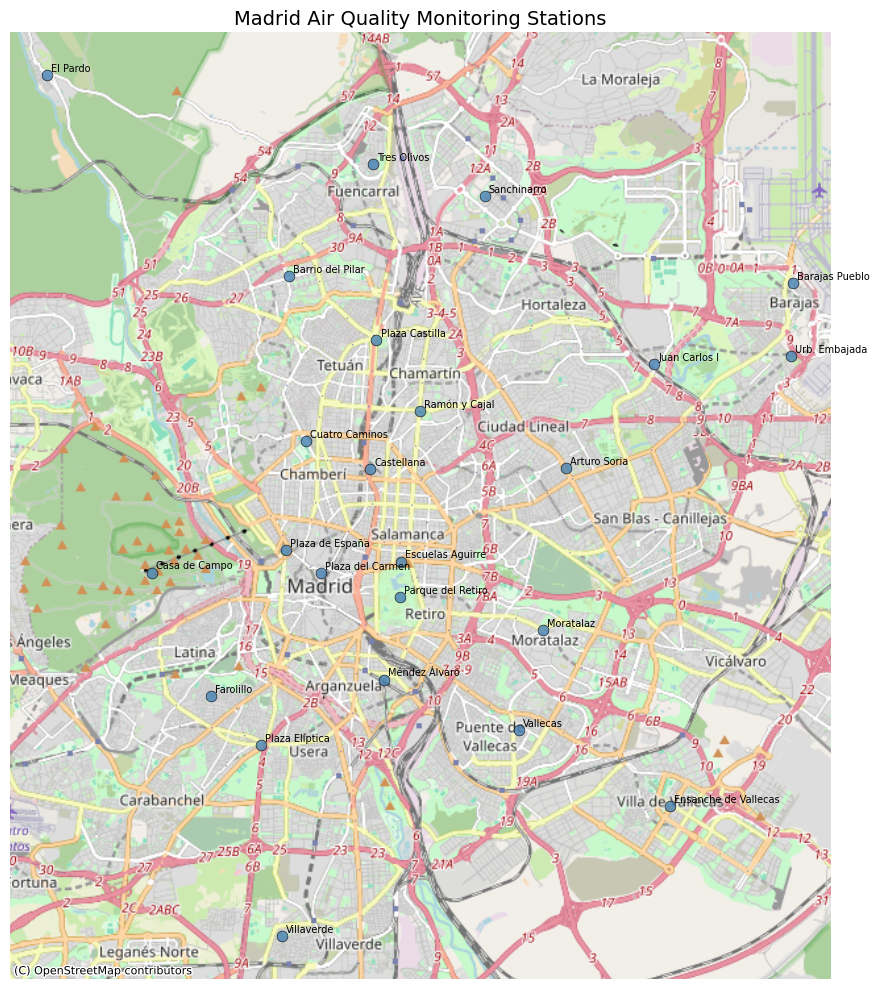

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf_simple.plot(ax=ax, color="steelblue", markersize=60, alpha=0.8,
                edgecolor="black", linewidth=0.5)

for _, row in gdf_simple.iterrows():
    ax.annotate(text=str(row["sensor_name"]),
                xy=(row.geometry.x, row.geometry.y),
                xytext=(3, 3), textcoords="offset points", fontsize=7)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title("Madrid Air Quality Monitoring Stations", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

#### 1.7) Initial Time-Series 


We now analyze the evolution of air pollution over time. The data is aggregated on a monthly basis by summing all pollutant values, resulting in the total pollution per month. We visualize this trend using a line plot, which shows how overall pollution levels have changed over time. This representation helps identify temporal patterns, trends, and potential peaks in pollution levels across the years.

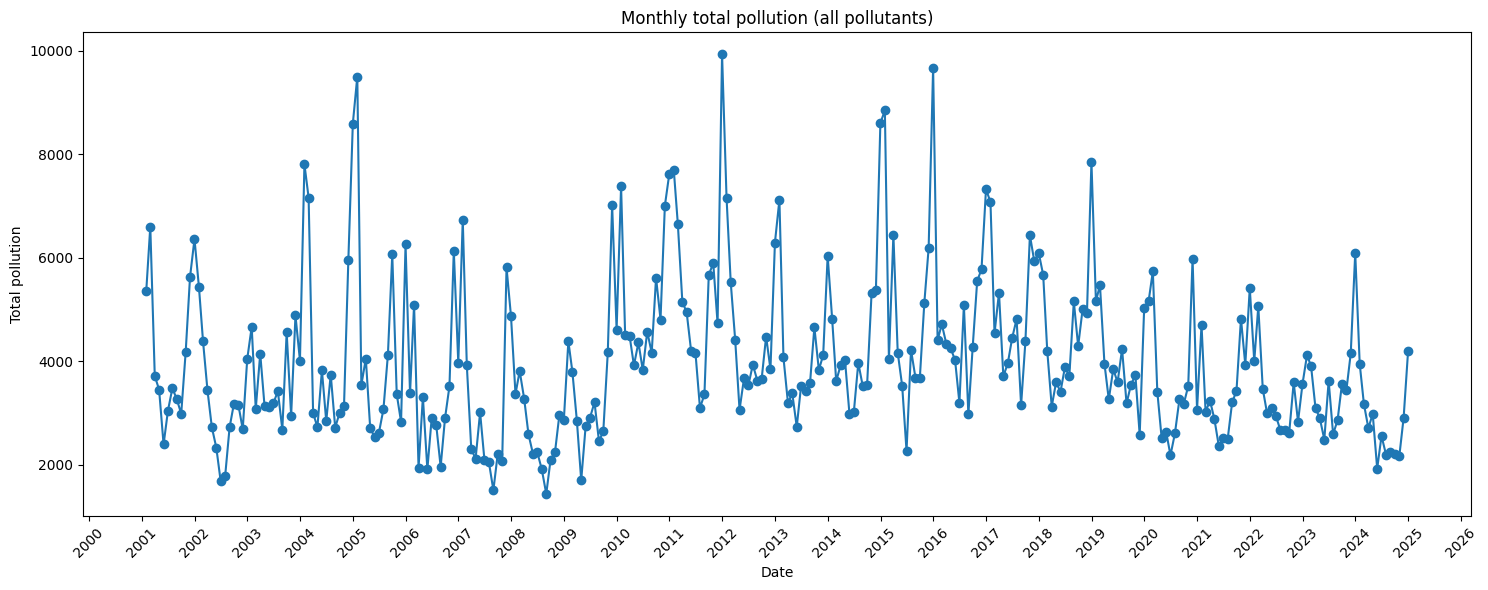

In [22]:
# copy data
df_ts = df_pollutants.copy()

# ensure datetime
df_ts["entry_date"] = pd.to_datetime(df_ts["entry_date"], errors="coerce")
df_ts = df_ts.dropna(subset=["entry_date"])

# set as index
df_ts = df_ts.set_index("entry_date")

# monthly aggregation
monthly_total = (
    df_ts["value"]
    .resample("ME")
    .sum()
    .reset_index())

# plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_total["entry_date"], monthly_total["value"], marker="o")

plt.title("Monthly total pollution (all pollutants)")
plt.xlabel("Date")
plt.ylabel("Total pollution")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We now analyze the evolution of the weather over time. The data is aggregated on a monthly basis by summing all weather values, resulting in the total weather per month. We visualize this trend using a line plot, which shows how overall pollution levels have changed over time. This representation helps identify temporal patterns, trends, and potential peaks in weather levels across the years.

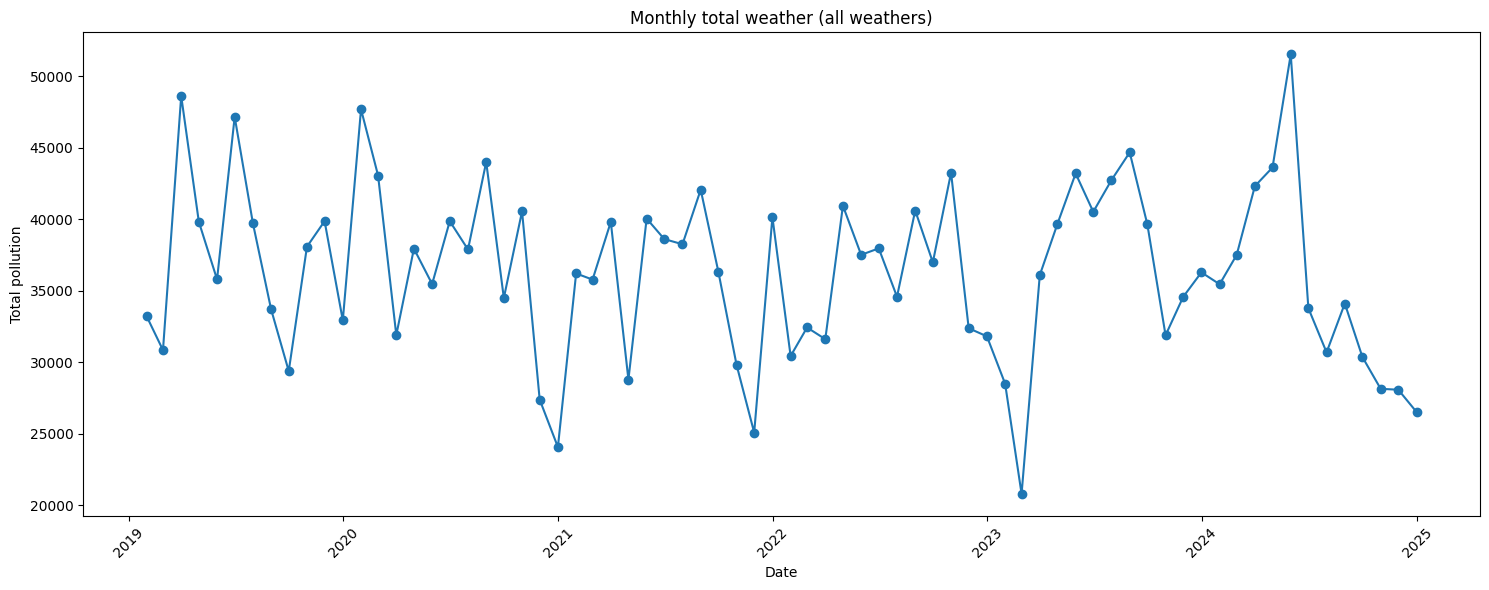

In [23]:
# copy data
df_ws = df_weather.copy()

# ensure datetime
df_ws["entry_date"] = pd.to_datetime(df_ws["entry_date"], errors="coerce")
df_ws = df_ws.dropna(subset=["entry_date"])

# set as index
df_ws = df_ws.set_index("entry_date")

# monthly aggregation 
monthly_total_w = (
    df_ws["value"]
    .resample("ME")
    .sum()
    .reset_index()
)

# plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_total_w["entry_date"], monthly_total_w["value"], marker="o")

plt.title("Monthly total weather (all weathers)")
plt.xlabel("Date")
plt.ylabel("Total pollution")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We now analyze the evolution of the traffic over time. The data is aggregated on a monthly basis by summing all traffic values, resulting in the total traffic per month. We visualize this trend using a line plot, which shows how overall pollution levels have changed over time. This representation helps identify temporal patterns, trends, and potential peaks in traffic levels across the years.

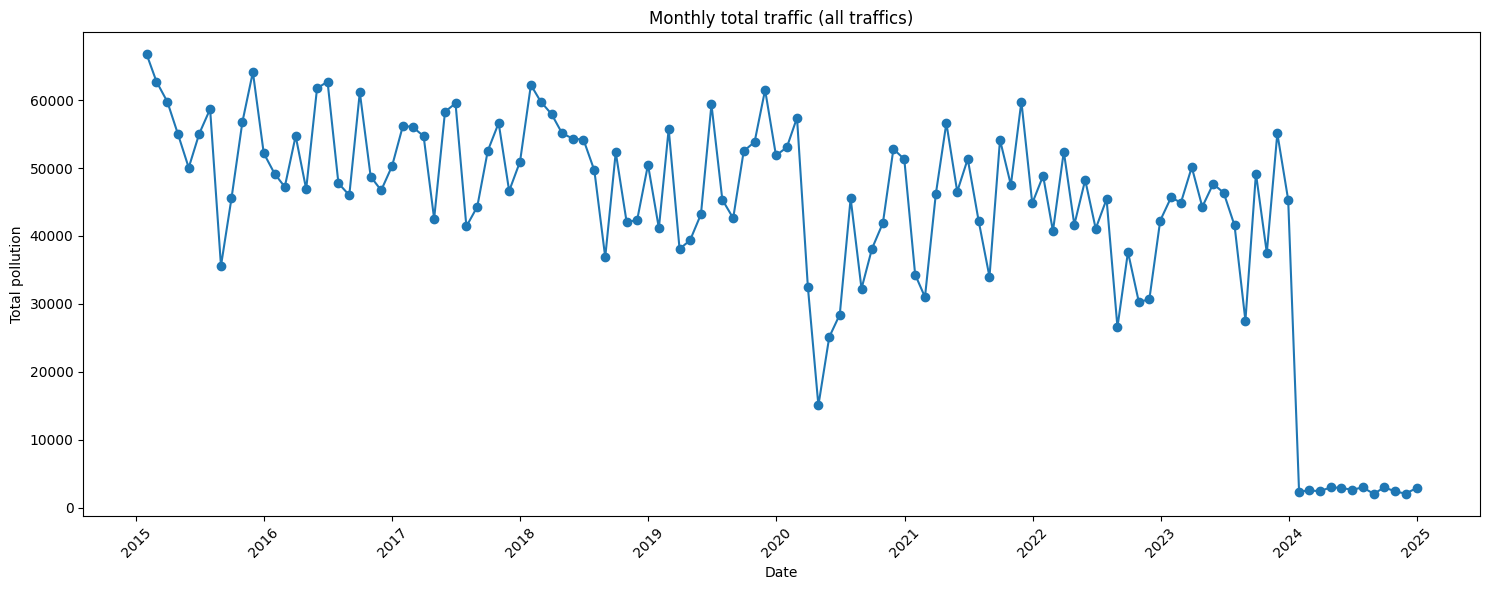

In [24]:
# copy data
df_tr = df_traffic.copy()

# ensure datetime
df_tr["entry_date"] = pd.to_datetime(df_tr["entry_date"], errors="coerce")
df_tr = df_tr.dropna(subset=["entry_date"])

# set as index
df_tr = df_tr.set_index("entry_date")

# monthly aggregation
monthly_total_t = (
    df_tr["value"]
    .resample("ME")
    .sum()
    .reset_index()
)

# plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_total_t["entry_date"], monthly_total_t["value"], marker="o")

plt.title("Monthly total traffic (all traffics)")
plt.xlabel("Date")
plt.ylabel("Total pollution")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.8) Distribution Plots (Histograms)

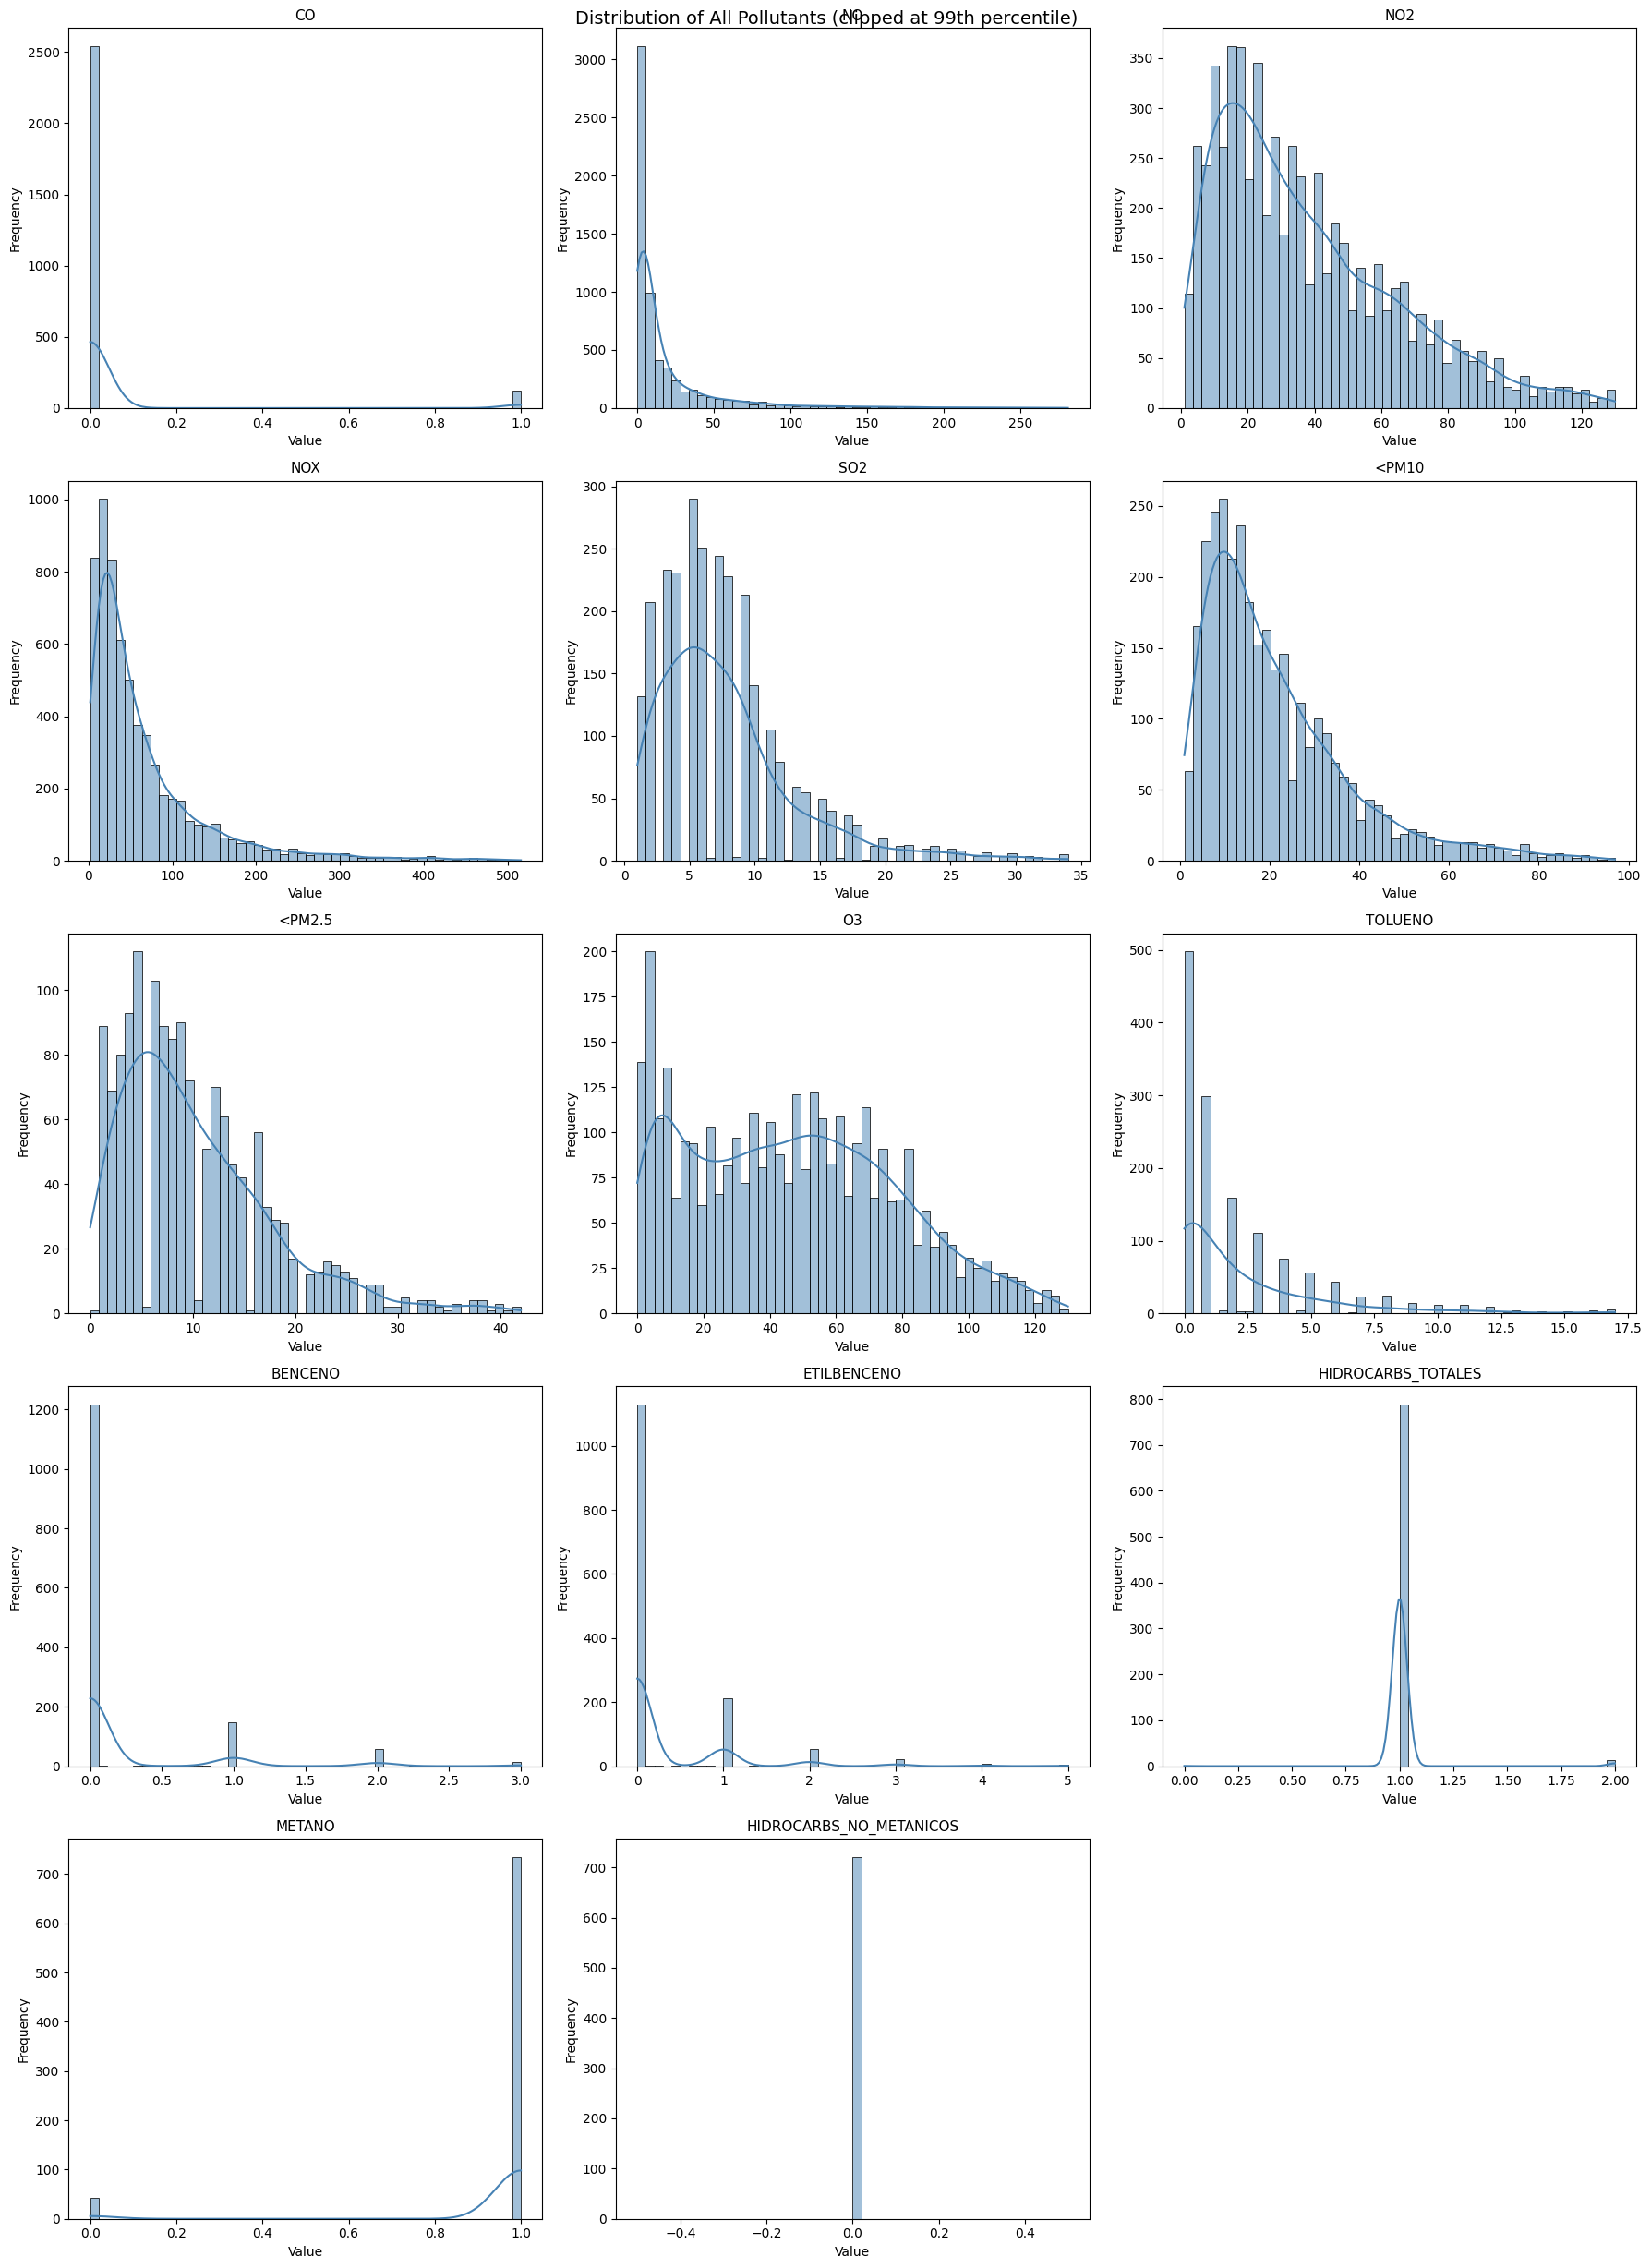

In [25]:
# Get all pollutants actually present in the dataset
all_pollutants_in_data = [p for p in pollutants if p in df_pollutants["magnitude_name"].values]

n = len(all_pollutants_in_data)
ncols = 3
nrows = (n + ncols - 1) // ncols  # enough rows to fit all

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax, pol in zip(axes, all_pollutants_in_data):
    data = df_pollutants[df_pollutants["magnitude_name"] == pol]["value"].dropna()
    cap = data.quantile(0.99)
    sns.histplot(data[data <= cap], ax=ax, kde=True, bins=50, color="steelblue")
    ax.set_title(pol, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

# Hide unused subplots
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Distribution of All Pollutants (clipped at 99th percentile)", fontsize=14)
plt.tight_layout()
plt.show()

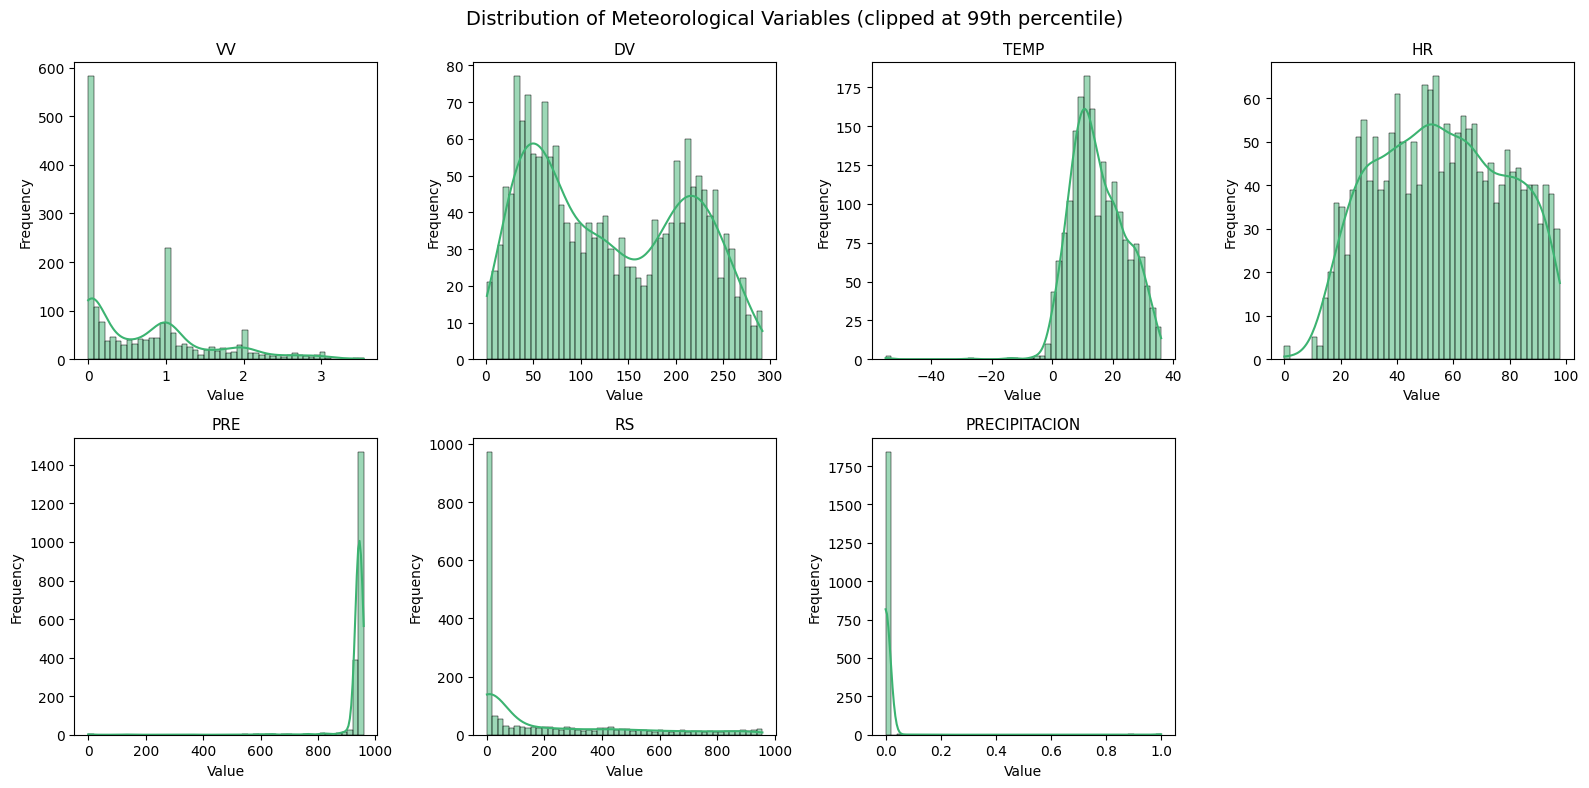

In [26]:
weather_in_data = [w for w in weather if w in df_weather["magnitude_name"].values]
n = len(weather_in_data)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, weather_in_data):
    data = df_weather[df_weather["magnitude_name"] == var]["value"].dropna()
    cap = data.quantile(0.99)
    sns.histplot(data[data <= cap], ax=ax, kde=True, bins=50, color="mediumseagreen")
    ax.set_title(var, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Distribution of Meteorological Variables (clipped at 99th percentile)", fontsize=14)
plt.tight_layout()
plt.show()

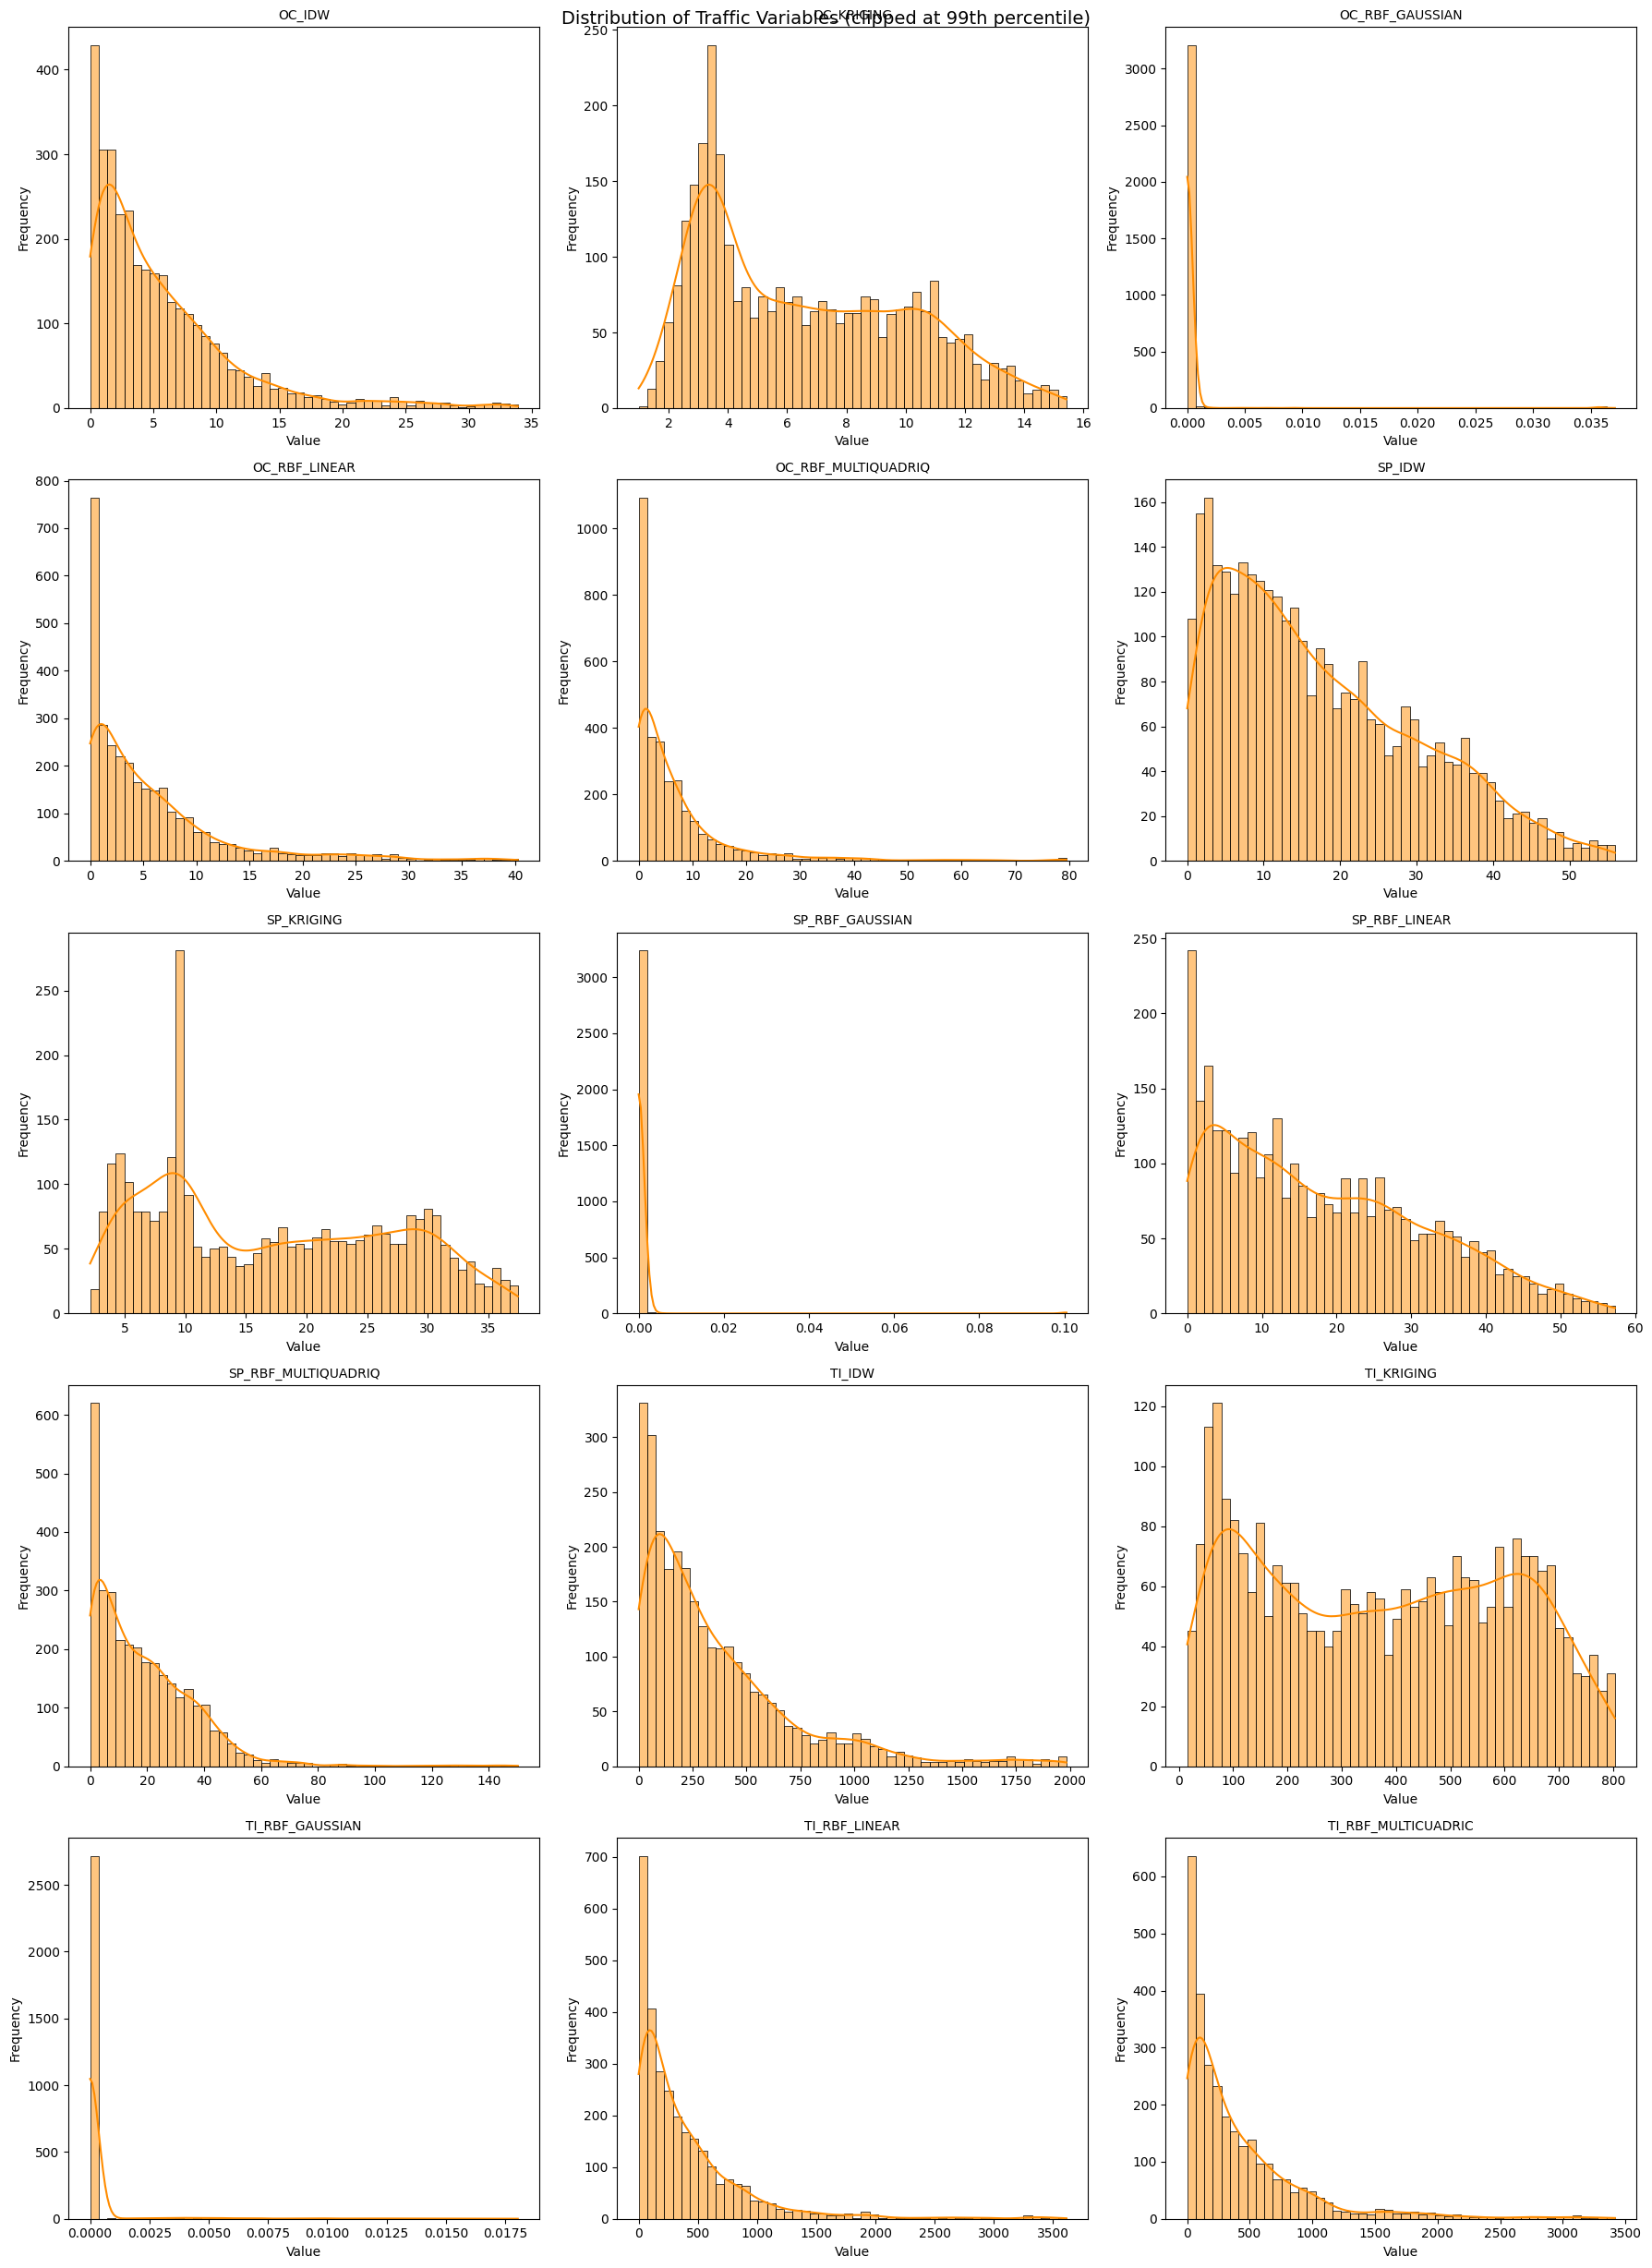

In [30]:
all_traffic_in_data = [t for t in traffic_vars if t in df_traffic["magnitude_name"].values]

n = len(all_traffic_in_data)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax, var in zip(axes, all_traffic_in_data):
    data = df_traffic[df_traffic["magnitude_name"] == var]["value"].dropna()
    cap = data.quantile(0.99)
    sns.histplot(data[data <= cap], ax=ax, kde=True, bins=50, color="darkorange")
    ax.set_title(var, fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle("Distribution of Traffic Variables (clipped at 99th percentile)", fontsize=14)
plt.tight_layout()
plt.show()

## **Task 2 — Missingness and Data Quality**
In this task we quantify where and how much data is missing, distinguish between different types of gaps, and detect invalid or inconsistent measurements that could compromise downstream analysis.

#### 2.1) Missingness per Column

The is_interpolated flag lets us reconstruct where data was originally missing. We start with a global overview: how many values across the entire dataset were originally absent and later filled.

In [ ]:
total = len(df)
total_interpolated = df["is_interpolated"].sum()
total_original = (~df["is_interpolated"]).sum()

print(f"Total records       : {total:,}")
print(f"Original values     : {total_original:,} ({100*total_original/total:.1f}%)")
print(f"Interpolated values : {total_interpolated:,} ({100*total_interpolated/total:.1f}%)")

Total records       : 100,000
Original values     : 88,842 (88.8%)
Interpolated values : 11,158 (11.2%)


#### 2.2) Missingness per Variable
We break down the interpolation rate by variable. This tells us which pollutants, weather or traffic variables suffered the most from missing data and were most heavily reconstructed.

In [ ]:
miss_per_var = (
    df.groupby(["magnitude_name", "variable_type"])["is_interpolated"]
    .agg(total="count", interpolated="sum")
    .assign(missing_rate=lambda x: (x["interpolated"] / x["total"]).round(3))
    .sort_values("missing_rate", ascending=False)
    .reset_index()
)
display(miss_per_var)

,magnitude_name,variable_type,total,interpolated,missing_rate
0,RS,weather,1928,1706,0.885
1,PRE,weather,1965,1729,0.880
2,DV,weather,1899,1584,0.834
3,VV,weather,1981,1646,0.831
4,PRECIPITACION,weather,1885,1469,0.779
5,HR,weather,1913,1095,0.572
6,TEMP,weather,1896,949,0.501
7,ETILBENCENO,pollutant,1449,77,0.053
8,BENCENO,pollutant,1458,70,0.048
9,TOLUENO,pollutant,1395,65,0.047


We visualize the top 20 variables with the highest interpolation rates as a bar chart.

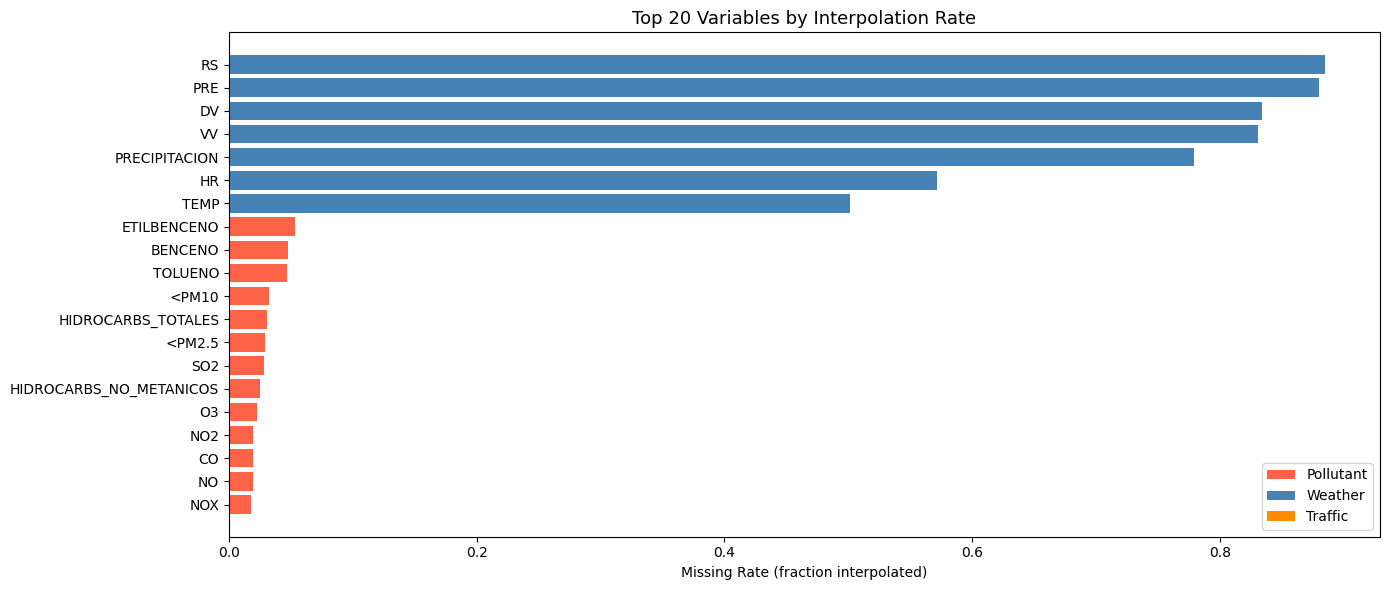

In [ ]:
top_missing = miss_per_var.head(20)

fig, ax = plt.subplots(figsize=(14, 6))
colors = top_missing["variable_type"].map(
    {"pollutant": "tomato", "weather": "steelblue", "traffic": "darkorange", "other": "grey"}
)
ax.barh(top_missing["magnitude_name"], top_missing["missing_rate"], color=colors)
ax.set_xlabel("Missing Rate (fraction interpolated)")
ax.set_title("Top 20 Variables by Interpolation Rate", fontsize=13)
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="tomato", label="Pollutant"),
    Patch(facecolor="steelblue", label="Weather"),
    Patch(facecolor="darkorange", label="Traffic"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

**What we observe:** Variables with high interpolation rates were frequently unavailable and rely heavily on reconstructed values. Traffic variables tend to have higher rates than pollutants, which is consistent with their shorter operational history. Variables above 50% interpolation should be used cautiously in modelling since the majority of their values are estimated rather than measured.

#### 2.3) Temporal Gaps — Missing Periods Over Time
A temporal gap occurs when an entire time period has no measurements — not just one sensor, but all sensors for a given variable. We identify these by checking which hours/days have no real (non-interpolated) observations.

In [ ]:
# Parse datetime
df["entry_dt"] = pd.to_datetime(df["entry_date"], errors="coerce")
df["date"] = df["entry_dt"].dt.date

# For each variable, count real (non-interpolated) measurements per day
real_counts = (
    df[~df["is_interpolated"]]
    .groupby(["magnitude_name", "date"])
    .size()
    .reset_index(name="real_count")
)

# Days with zero real measurements = temporal gap
all_days = df.groupby(["magnitude_name", "date"]).size().reset_index(name="total_count")
gap_days = all_days.merge(real_counts, on=["magnitude_name", "date"], how="left")
gap_days["real_count"] = gap_days["real_count"].fillna(0)
gap_days["is_gap"] = gap_days["real_count"] == 0

temporal_gaps = (
    gap_days.groupby("magnitude_name")["is_gap"]
    .agg(total_days="count", gap_days="sum")
    .assign(gap_rate=lambda x: (x["gap_days"] / x["total_days"]).round(3))
    .sort_values("gap_days", ascending=False)
    .reset_index()
)
display(temporal_gaps)

,magnitude_name,total_days,gap_days,gap_rate
0,PRE,1307,1083,0.829
1,RS,1289,1077,0.836
2,VV,1312,1003,0.764
3,DV,1261,961,0.762
4,PRECIPITACION,1271,895,0.704
5,HR,1276,586,0.459
6,TEMP,1261,494,0.392
7,<PM10,2668,79,0.030
8,ETILBENCENO,1307,68,0.052
9,SO2,2377,61,0.026


We visualize temporal gaps for the most affected pollutants as a heatmap — each row is a pollutant, each column is a month, green = data available, red = complete gap.

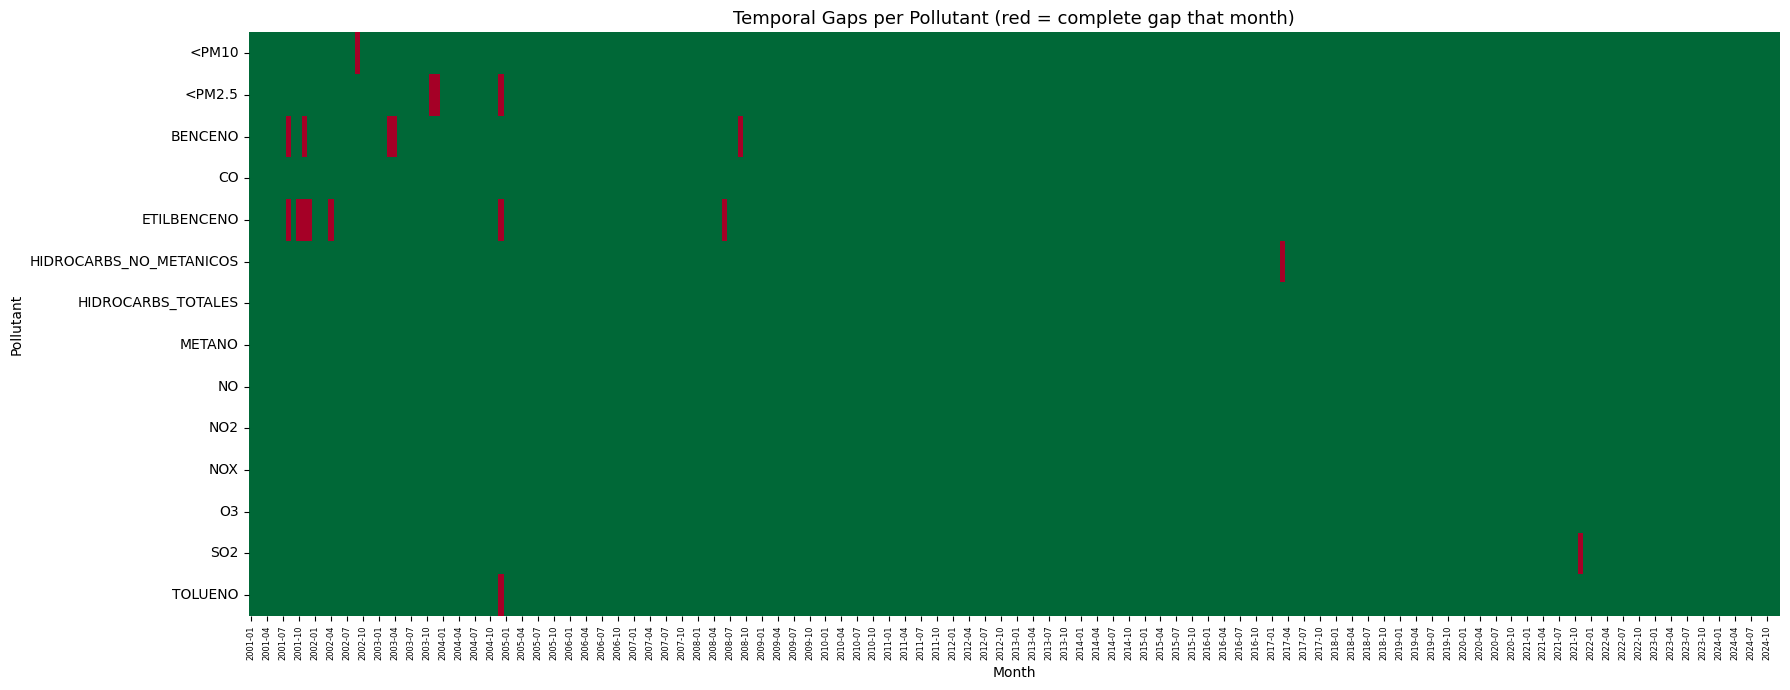

In [ ]:
# Focus on pollutants only
pollutant_gaps = gap_days[gap_days["magnitude_name"].isin(pollutants)].copy()
pollutant_gaps["month"] = pd.to_datetime(pollutant_gaps["date"]).dt.to_period("M").astype(str)

gap_heatmap = (
    pollutant_gaps.groupby(["magnitude_name", "month"])["is_gap"]
    .all()
    .unstack("month")
    .fillna(False)
)

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    gap_heatmap.astype(int),
    cmap="RdYlGn_r",
    ax=ax,
    cbar=False,
    linewidths=0
)
ax.set_title("Temporal Gaps per Pollutant (red = complete gap that month)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Pollutant")
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

**What we observe:** Temporal gaps are not random — they tend to cluster in early years when fewer sensors were operational, and some pollutants were not monitored at all until later periods. Gaps that span entire months indicate that a variable was simply not yet introduced into the monitoring network, rather than a sensor malfunction. This reinforces the importance of the time window decision made in Task 1.

#### 2.4) Partial vs Full Timestamp Missingness

The PDF highlights a specific pattern: at a given timestamp, only some variables may be missing while others are present. We distinguish between timestamps where all variables are missing (likely a full sensor outage) versus timestamps where only specific variables are absent (isolated measurement failure).

In [ ]:
timestamp_miss = (
    df.groupby(["sensor_name", "entry_date"])["is_interpolated"]
    .agg(total="count", missing="sum")
    .assign(
        all_missing=lambda x: x["missing"] == x["total"],
        partial_missing=lambda x: (x["missing"] > 0) & (x["missing"] < x["total"]),
        none_missing=lambda x: x["missing"] == 0
    )
)

print(f"Timestamps where ALL variables missing  : {timestamp_miss['all_missing'].sum():,}")
print(f"Timestamps where SOME variables missing : {timestamp_miss['partial_missing'].sum():,}")
print(f"Timestamps where NO variables missing   : {timestamp_miss['none_missing'].sum():,}")

Timestamps where ALL variables missing  : 10,758
Timestamps where SOME variables missing : 338
Timestamps where NO variables missing   : 87,304


#### 2.5) Sensor-Specific Gaps
A sensor-specific gap occurs when one station is missing data while others are still reporting. These are more localised and may indicate sensor malfunctions, maintenance periods, or station-level issues.

In [ ]:
# For each sensor + variable combination, compute the interpolation rate
sensor_miss = (
    df.groupby(["sensor_name", "magnitude_name"])["is_interpolated"]
    .agg(total="count", interpolated="sum")
    .assign(rate=lambda x: (x["interpolated"] / x["total"]).round(3))
    .reset_index()
    .sort_values("rate", ascending=False)
)

display(sensor_miss[sensor_miss["rate"] > 0.5].head(20))

,sensor_name,magnitude_name,total,interpolated,rate
684,Villaverde,VV,92,92,1.0
585,Tres Olivos,PRECIPITACION,65,65,1.0
188,El Pardo,PRE,76,76,1.0
189,El Pardo,PRECIPITACION,79,79,1.0
190,El Pardo,RS,80,80,1.0
574,Tres Olivos,HR,79,79,1.0
573,Tres Olivos,DV,61,61,1.0
571,Sanchinarro,VV,76,76,1.0
202,El Pardo,VV,84,84,1.0
565,Sanchinarro,TEMP,91,91,1.0


We visualize sensor-specific missingness as a heatmap for pollutants — rows are sensors, columns are pollutants.

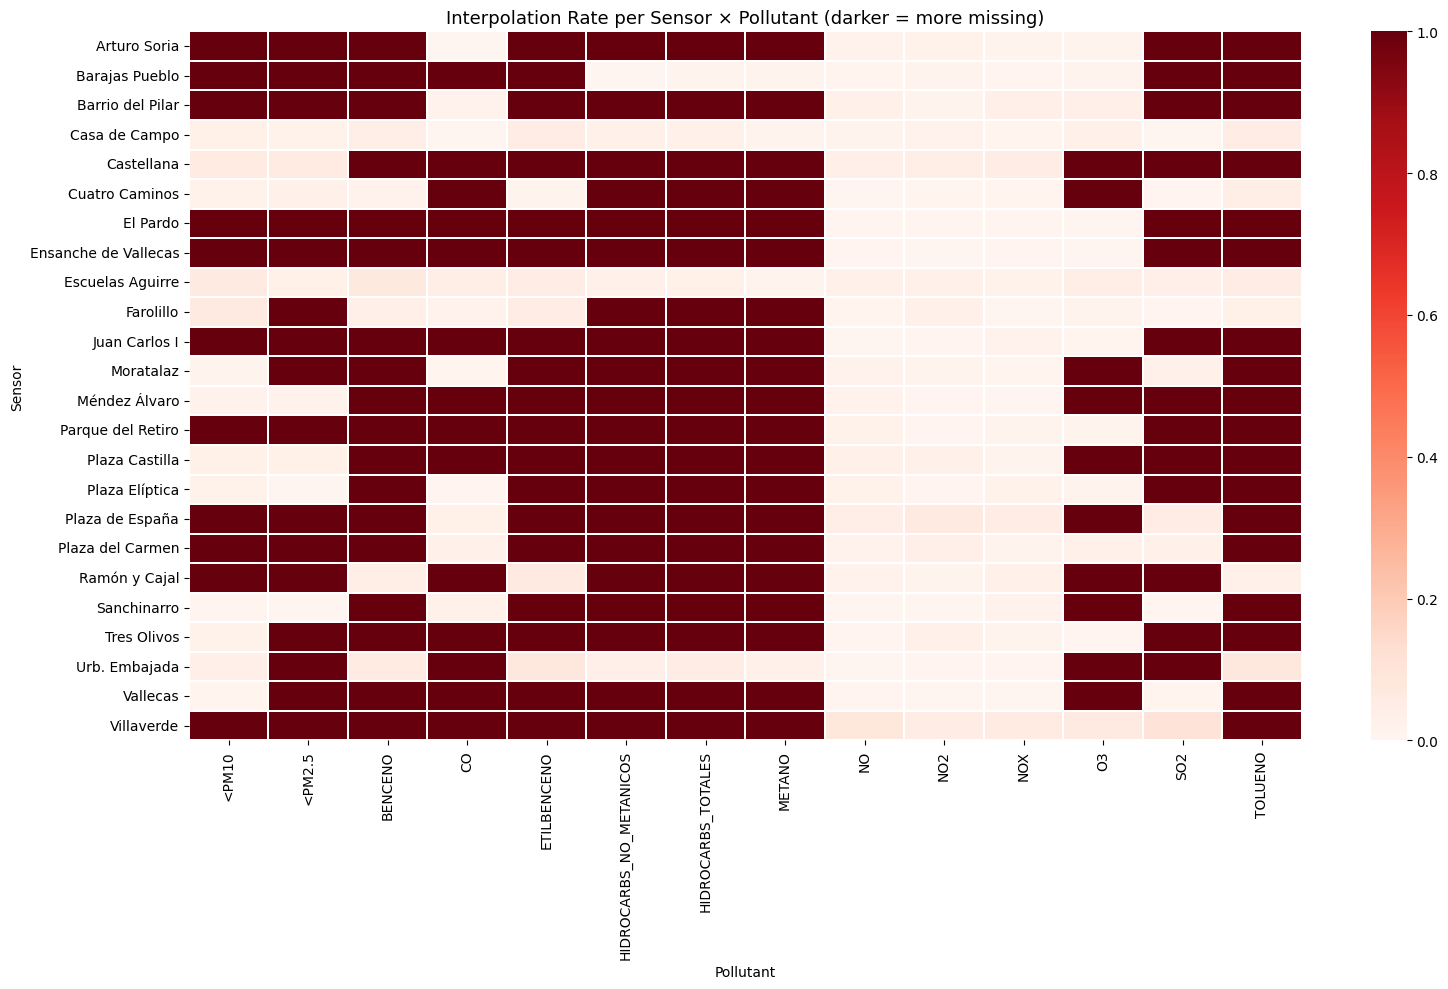

In [ ]:
# Pivot: sensors × pollutants, value = interpolation rate
sensor_pollutant_miss = (
    df[df["variable_type"] == "pollutant"]
    .groupby(["sensor_name", "magnitude_name"])["is_interpolated"]
    .mean()
    .unstack("magnitude_name")
    .fillna(1.0)  # if a sensor never measured a pollutant, treat as fully missing
)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    sensor_pollutant_miss,
    cmap="Reds",
    ax=ax,
    linewidths=0.3,
    vmin=0,
    vmax=1,
    annot=False
)
ax.set_title("Interpolation Rate per Sensor × Pollutant (darker = more missing)", fontsize=13)
ax.set_xlabel("Pollutant")
ax.set_ylabel("Sensor")
plt.tight_layout()
plt.show()

**What we observe:** The heatmap reveals that missingness is highly uneven across sensors. Some stations are almost entirely interpolated for certain pollutants, meaning they contributed almost no real measurements for those variables. These sensor-pollutant combinations should be excluded or treated carefully in any analysis that requires reliable ground-truth data.

#### 2.6) Monthly Interpolation Rate per Sensor Over Time

Beyond knowing which sensors are missing data overall, we want to see *when* they were missing. A sensor might have a long uninterrupted outage in one specific year due to maintenance or malfunction, which would not be visible in an overall average. We plot the monthly interpolation rate per sensor to reveal these temporal patterns.

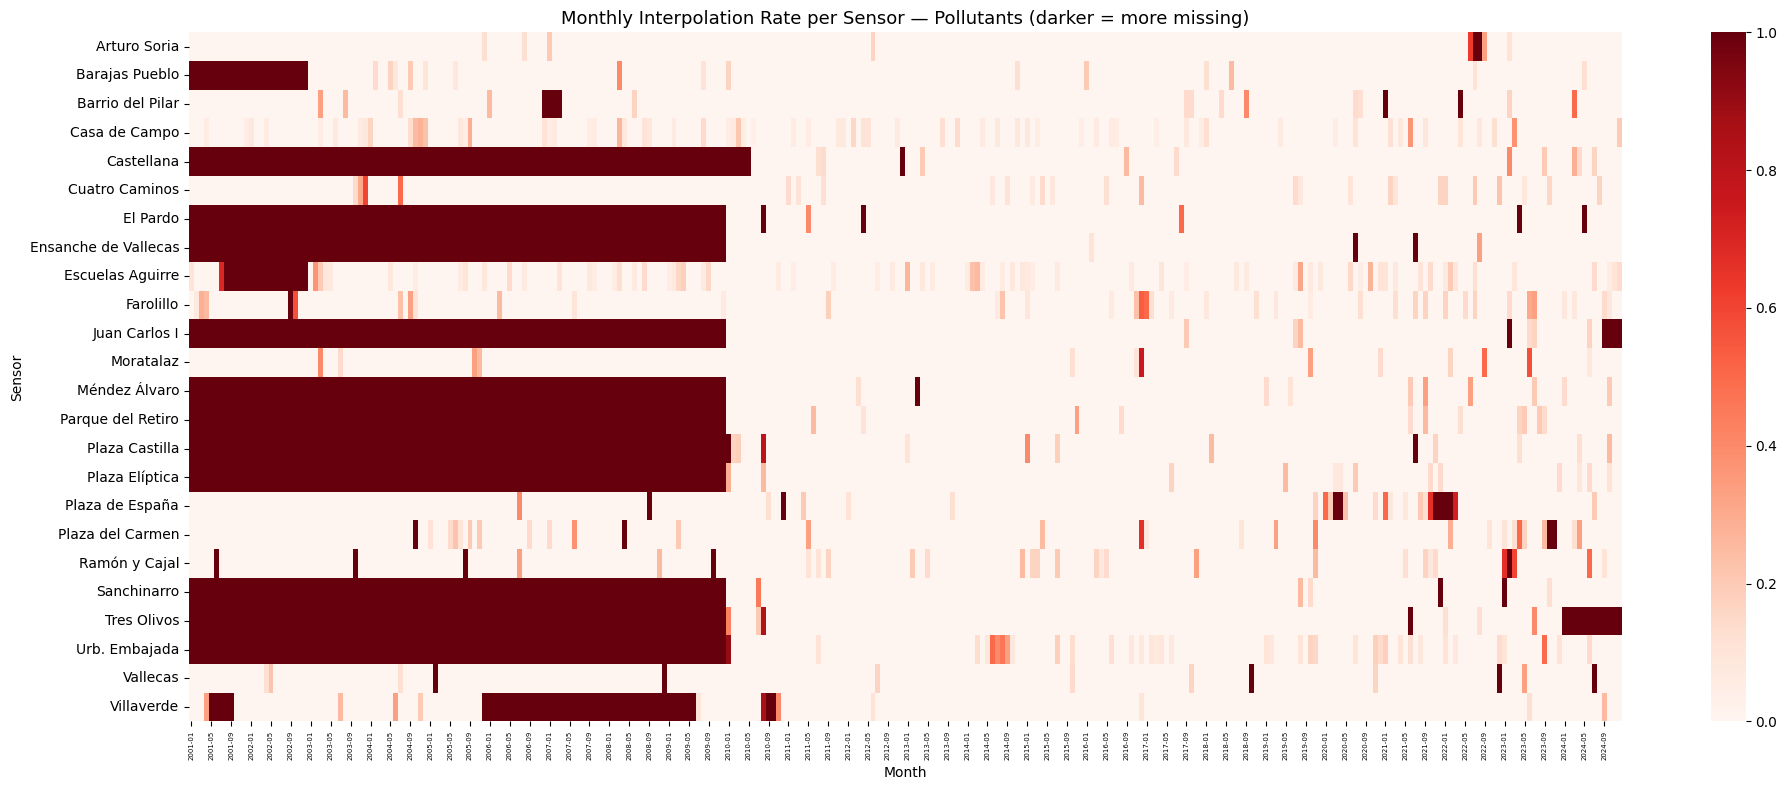

In [ ]:
df_poll_copy = df_pollutants.copy()
df_poll_copy["entry_dt"] = pd.to_datetime(df_poll_copy["entry_date"], errors="coerce")
df_poll_copy["month"] = df_poll_copy["entry_dt"].dt.to_period("M").astype(str)

sensor_monthly_miss = (
    df_poll_copy.groupby(["sensor_name", "month"])["is_interpolated"]
    .mean()
    .unstack("month")
    .fillna(1.0)
)

fig, ax = plt.subplots(figsize=(20, 8))
sns.heatmap(
    sensor_monthly_miss,
    cmap="Reds",
    ax=ax,
    cbar=True,
    linewidths=0,
    vmin=0,
    vmax=1
)
ax.set_title("Monthly Interpolation Rate per Sensor — Pollutants (darker = more missing)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Sensor")
plt.xticks(rotation=90, fontsize=5)
plt.tight_layout()
plt.show()

#### 2.7) Invalid and Inconsistent Values
The is_interpolated flag does not guarantee data quality — real measurements can also be erroneous. We check for several types of invalid values:

In [ ]:
issues = {}

# 1. Negative pollutant concentrations (physically impossible)
neg = df[(df["variable_type"] == "pollutant") & (df["value"] < 0)]
issues["Negative pollutant values"] = len(neg)

# 2. Extreme outliers: values beyond 5 standard deviations from the mean per variable
def flag_outliers(group):
    mean = group["value"].mean()
    std  = group["value"].std()
    return group[np.abs(group["value"] - mean) > 5 * std]

outliers = (
    df[df["variable_type"] == "pollutant"]
    .groupby("magnitude_name", group_keys=False)
    .apply(flag_outliers)
)
issues["Extreme outliers (>5σ) in pollutants"] = len(outliers)

# 3. Zero values for variables that should never be zero (e.g. atmospheric pressure)
zero_pressure = df[(df["magnitude_name"] == "PRE") & (df["value"] == 0)]
issues["Zero atmospheric pressure readings"] = len(zero_pressure)

# 4. Duplicate timestamps: same sensor + variable + timestamp with different values
dupes = df.duplicated(subset=["sensor_name", "magnitude_name", "entry_date"], keep=False)
issues["Duplicate sensor/variable/timestamp entries"] = dupes.sum()

for issue, count in issues.items():
    print(f"{issue}: {count:,}")

Negative pollutant values: 0
Extreme outliers (>5σ) in pollutants: 224
Zero atmospheric pressure readings: 2
Duplicate sensor/variable/timestamp entries: 0


In [ ]:
# Show breakdown of extreme outliers per pollutant
if len(outliers) > 0:
    outlier_summary = (
        outliers.groupby("magnitude_name")["value"]
        .agg(["count", "min", "max", "mean"])
        .rename(columns={"count": "n_outliers"})
        .sort_values("n_outliers", ascending=False)
    )
    display(outlier_summary)

,n_outliers,min,max,mean
magnitude_name,,,,
NO,60,289.0,700.0,396.233333
NOX,52,591.0,1819.0,783.057692
CO,23,2.0,8.0,2.695652
SO2,19,44.0,129.0,57.631579
<PM10,15,132.0,335.0,189.866667
HIDROCARBS_TOTALES,14,0.0,2.0,1.857143
ETILBENCENO,12,6.0,15.0,7.666667
BENCENO,9,6.0,17.0,9.555556
NO2,9,193.0,270.0,217.888889


**What we observe:** Invalid values can occur even in non-interpolated measurements, confirming that the is_interpolated flag alone is not sufficient as a quality filter. Extreme outliers may result from sensor malfunctions, calibration errors, or unusual atmospheric events. Before any modelling task, these values should be removed or capped. Duplicate entries, if present, suggest data pipeline issues and must be deduplicated.

#### 2.8) Chemical Consistency Check — NOX = NO + NO2

Beyond range checks, we can verify internal consistency between chemically related variables. By definition, NOX (nitrogen oxides) is the sum of NO and NO2. Any row where this relationship is badly violated likely represents a sensor calibration error or a data pipeline issue, and is invalid regardless of whether it was flagged as interpolated.

In [ ]:
nox_check = df[df["magnitude_name"].isin(["NO", "NO2", "NOX"])].copy()
nox_wide = (
    nox_check.groupby(["sensor_name", "entry_date", "magnitude_name"])["value"]
    .mean()
    .unstack("magnitude_name")
    .dropna()
)

if all(col in nox_wide.columns for col in ["NOX", "NO", "NO2"]):
    nox_wide["expected_NOX"] = nox_wide["NO"] + nox_wide["NO2"]
    nox_wide["nox_error"] = np.abs(nox_wide["NOX"] - nox_wide["expected_NOX"])
    nox_wide["nox_error_pct"] = (
        nox_wide["nox_error"] / nox_wide["expected_NOX"].replace(0, np.nan) * 100
    )

    n_inconsistent = (nox_wide["nox_error_pct"] > 20).sum()
    print(f"Rows where NOX differs from NO+NO2 by more than 20%: {n_inconsistent:,}")
    print(f"Mean absolute error: {nox_wide['nox_error'].mean():.2f}")

    if n_inconsistent > 0:
        display(nox_wide[nox_wide["nox_error_pct"] > 20].head(10))
else:
    print("One or more of NO, NO2, NOX not present in this dataset sample.")

Rows where NOX differs from NO+NO2 by more than 20%: 0
Mean absolute error: nan


#### 2.9) Summary of Data Quality Issues
We consolidate all quality findings into a single summary table for reference in later tasks.

In [ ]:
quality_summary = pd.DataFrame({
    "Issue": [
        "Interpolated values (all variables)",
        "Negative pollutant readings",
        "Extreme outliers (>5σ) in pollutants",
        "Zero atmospheric pressure readings",
        "Duplicate entries",
        "NOX ≠ NO + NO2 inconsistencies (>20% error)"
    ],
    "Count": [
        int(df["is_interpolated"].sum()),
        len(neg),
        len(outliers),
        len(zero_pressure),
        int(dupes.sum()),
        int((nox_wide["nox_error_pct"] > 20).sum()) if "nox_error_pct" in nox_wide.columns else 0
    ]
})
quality_summary["Rate (%)"] = (
    quality_summary["Count"] / len(df) * 100
).round(3)

display(quality_summary)

,Issue,Count,Rate (%)
0,Interpolated values (all variables),11158,11.158
1,Negative pollutant readings,0,0.000
2,Extreme outliers (>5σ) in pollutants,224,0.224
3,Zero atmospheric pressure readings,2,0.002
4,Duplicate entries,0,0.000
5,NOX ≠ NO + NO2 inconsistencies (>20% error),0,0.000


**Summary:** The dataset contains several types of data quality issues that must be addressed before analysis. The most prevalent is interpolation, which affects a significant fraction of all records. Sensor-specific gaps are highly uneven, meaning some station-variable combinations are almost entirely reconstructed. Extreme outliers and invalid values, while rarer, could disproportionately affect statistical results if not handled. In Task 3 we will design and compare imputation strategies to address the missingness.

## **Task 3 — Imputation**

## **Task 4 — Temporal Analysis**

## **Task 5 — Spatial Network**

## **Task 6 — Correlation Network**

## **Task 7 — Propagation Modeling (Optional)**

## **Task 8 — Parallelization**

## **Task 9 — Forecasting Model (Optional)**

## **Task 10 — Final Visualization**